In [1]:
%pip install --quiet python-dotenv pydantic-ai ffmpeg-python yt-dlp

import os
from pathlib import Path
import nest_asyncio; nest_asyncio.apply()

# Download data files if not already present (e.g. on Colab)
if not Path("data").exists():
    import zipfile, urllib.request
    url = "https://github.com/jsoma/workshop-ai-images-video/raw/main/docs/nicar-2026/04-video-data.zip"
    print("Downloading data...")
    urllib.request.urlretrieve(url, "_data.zip")
    with zipfile.ZipFile("_data.zip") as zf:
        zf.extractall("data")
    Path("_data.zip").unlink()
    print("Done!")

# Paste API keys here or leave empty for .env / Colab secrets
api_keys = {"OPENAI_API_KEY": "", "GOOGLE_API_KEY": ""}
os.environ.update({k: v for k, v in api_keys.items() if v})
try:
    from google.colab import userdata
    for key in api_keys:
        try: os.environ.setdefault(key, userdata.get(key))
        except Exception: pass
except ImportError:
    from dotenv import load_dotenv; load_dotenv()

DATA = Path("data")
Path("outputs").mkdir(exist_ok=True)


/Users/soma/Library/CloudStorage/Dropbox/Soma/Curriculum/2026-nicar/01-fri-analyzing-images-videos-ai/ai-images-video/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Video

You've got image tools and audio tools. Video is both — frames and a soundtrack — so you already have everything you need! Yes, you could send it to Gemini or another LLM (which we do at the end), but you can also just decompose it and reuse what you've learned.

## Download

[yt-dlp](https://github.com/yt-dlp/yt-dlp) is the best tool for downloading video content on the internet. It's gotten less effect at YouTube in the past 6 months or so, but it's still great for older videos and non-YT sites. Always try it out first!


**`video/download.py`** — Download a video from YouTube with yt-dlp


In [ ]:
from pathlib import Path
import yt_dlp

DATA = Path("data")
URL = "https://www.youtube.com/watch?v=rDXubdQdJYs"

DATA.mkdir(parents=True, exist_ok=True)

ydl_opts = {
    "outtmpl": str(DATA / "%(id)s.%(ext)s"),
    "quiet": True,
    "no_warnings": True,
}

with yt_dlp.YoutubeDL(ydl_opts) as ydl:
    ydl.download([URL])


## Extract frames

Since you know how to analyze images, why not just separate out the frames in a video? Below we extract one frame every two seconds. Now you have images: use the image tools!


**`video/frames.py`** — Extract frames from a video at 1 frame every 2 seconds using ffmpeg-python


In [ ]:
import ffmpeg
from pathlib import Path

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
OUTPUT = Path("outputs") / "frames"
OUTPUT.mkdir(parents=True, exist_ok=True)

(
    ffmpeg
    .input(str(VIDEO))
    .filter("fps", fps=0.5)
    .output(str(OUTPUT / "frame_%04d.jpg"), **{"qscale:v": 2})
    .overwrite_output()
    .run(quiet=True)
)

frames = sorted(OUTPUT.glob("frame_*.jpg"))
print(f"Extracted {len(frames)} frames to {OUTPUT}")


Extracted 59 frames to outputs/frames


Preview: a sample of what we just extracted.


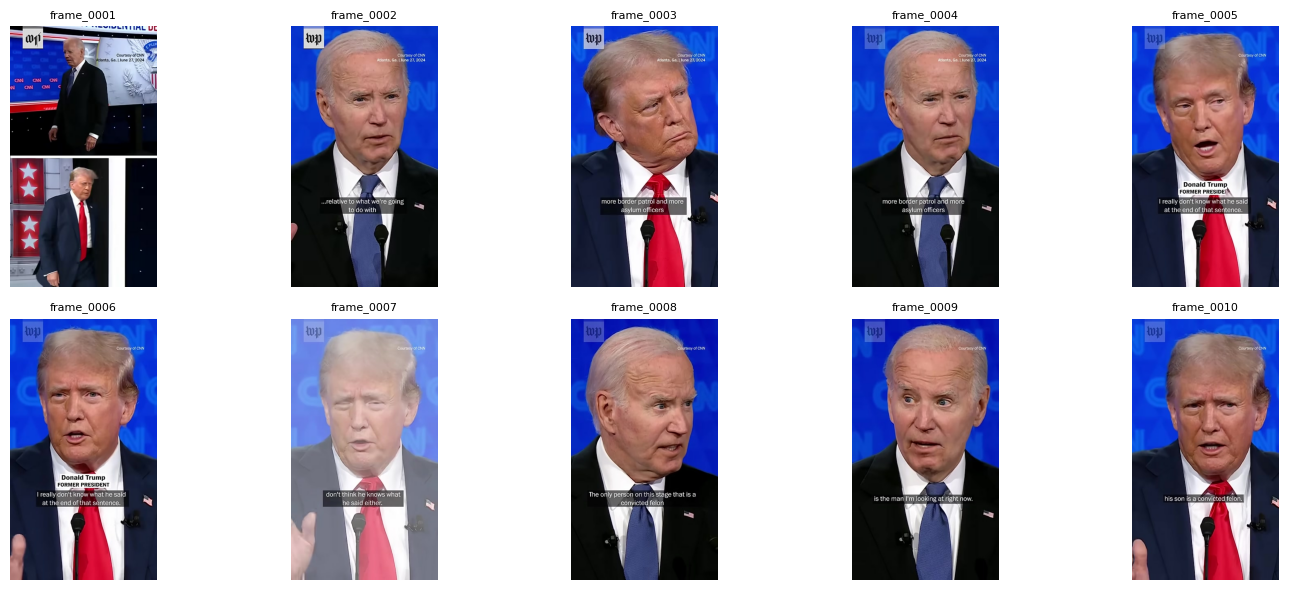

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

sample = frames[:10]
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, path in zip(axes.flat, sample):
    ax.imshow(Image.open(path))
    ax.set_title(path.stem, fontsize=8)
    ax.axis("off")
plt.tight_layout()


## Extract audio

Same thing for the audio. Now you have audio: use the audio tools!


**`video/audio.py`** — Extract audio track from a video file using ffmpeg-python


In [2]:
import ffmpeg
from pathlib import Path

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
OUTPUT = Path("outputs")
OUTPUT.mkdir(parents=True, exist_ok=True)

(
    ffmpeg
    .input(str(VIDEO))
    .output(str(OUTPUT / "rDXubdQdJYs.mp3"), acodec="libmp3lame", vn=None)
    .overwrite_output()
    .run(quiet=True)
)

print(f"Audio saved to {OUTPUT / 'rDXubdQdJYs.mp3'}")


Audio saved to outputs/rDXubdQdJYs.mp3


## Answering quetsions the slightly risky way

Just like you can ask AI about images, you can also ask about videos! ...at least, for some of the models. Gemini is probably the best: ask a question about the video, get a confident answer. It... may or may not be accurate.


**`video/vibe-answer.py`** — The risky way: ask Gemini "who got more screen time?" -- confident answer, no evidence


In [ ]:
import time
from pathlib import Path

from pydantic_ai import Agent, VideoUrl
from pydantic_ai.providers.google import GoogleProvider

DATA = Path("data")
VIDEO = DATA / "rDXubdQdJYs.mp4"
MODEL = "google-gla:gemini-2.5-flash"

provider = GoogleProvider()
video_file = provider.client.files.upload(file=str(VIDEO))

while video_file.state.name == "PROCESSING":
    time.sleep(5)
    video_file = provider.client.files.get(name=video_file.name)

agent = Agent(MODEL)
result = agent.run_sync([
    "Who got more screen time in this debate video? "
    "Give me a breakdown of approximately how much time each person was on screen.",
    VideoUrl(url=video_file.uri, media_type=video_file.mime_type),
])

print(result.output)


Based on an approximate breakdown of the video:

*   **Joe Biden:** Approximately **33 seconds**
*   **Donald Trump:** Approximately **25 seconds**

**Joe Biden** got more screen time in this video.


> Gemini's raw API docs: [video](https://ai.google.dev/gemini-api/docs/video-understanding), [audio](https://ai.google.dev/gemini-api/docs/audio).

While it's *convenient*, using Gemini is slightly more difficult to fact-check. It's harder to show your editor the work, errors are hidden behind a wall of "just trust me!" It's a vibe, for better or worse. 


## The boring (auditable) way

Instead of getting Gemini to go whole-hog on the video analysis, we use our other skills: split into frames, classify each frame with an LLM. Produce an auditable CSV, where every row links to a frame you can check.


**`video/decompose-classify.py`** — The auditable way: classify each frame with Pydantic AI, produce an auditable CSV


In [ ]:
from pathlib import Path
import pandas as pd
from pydantic import BaseModel
from pydantic_ai import Agent, BinaryContent

DATA = Path("data")
MODEL = "openai:gpt-5-nano"
FRAMES_DIR = DATA / "debate"
OUTPUT = Path("outputs") / "frame_classifications.csv"

class FrameClassification(BaseModel):
    subject: str
    confidence: float
    speaking: bool
    description: str

agent = Agent(
    MODEL,
    output_type=FrameClassification,
    system_prompt="Classify frames from a political debate. Identify who is on screen, confidence 0-1, whether they are speaking.",
)

frames = sorted(FRAMES_DIR.glob("*.jpg"))
OUTPUT.parent.mkdir(parents=True, exist_ok=True)

rows = []
for i, path in enumerate(frames):
    r = agent.run_sync([
        f"Frame {i}",
        BinaryContent(data=path.read_bytes(), media_type="image/jpeg"),
    ])
    rows.append({"frame": i, **r.output.model_dump()})
    print(f"{path.name}: {r.output.subject} ({r.output.confidence:.2f})")


frame-001.jpg: Frame 0: Biden (top) and Trump (bottom) (0.70)


frame-002.jpg: Joe Biden (0.92)


frame-003.jpg: Unknown male political figure (0.75)


frame-004.jpg: Joe Biden (0.78)


frame-005.jpg: Unknown person (0.65)


...

frame_0054.jpg: Joe Biden (0.78)


frame_0055.jpg: Unknown male political figure on screen (0.90)


frame_0056.jpg: Unidentified speaker (0.82)


frame_0057.jpg: Unknown male politician in a debate (frame shows a debate participant) (0.68)


frame_0058.jpg: Unknown male politician (0.75)


Every frame is now a row. You can sort, filter, and fact-check any one of them.


In [ ]:
df = pd.DataFrame(rows)
df.to_csv(OUTPUT, index=False)
print(f"Saved {len(df)} frames to {OUTPUT}")

df


Saved 89 frames to outputs/frame_classifications.csv


,frame,subject,confidence,speaking,description
0,0,Frame 0: Biden (top) and Trump (bottom),0.70,False,Two-panel frame: top panel shows Joe Biden in ...
1,1,Joe Biden,0.92,True,Frame 1: Close-up of Joe Biden with white hair...
2,2,Unknown male political figure,0.75,False,Frame 2 shows a male on stage wearing a dark s...
3,3,Joe Biden,0.78,True,"Close-up of Joe Biden at a debate podium, wear..."
4,4,Unknown person,0.65,True,Frame 4 shows a man in a dark suit with a red ...
...,...,...,...,...,...
84,84,Joe Biden,0.78,True,Frame 84 shows Joe Biden speaking on a debate ...
85,85,Unknown male political figure on screen,0.90,True,Frame 85 shows an older man in a suit speaking...
86,86,Unidentified speaker,0.82,True,Close-up of an older man with white hair weari...
87,87,Unknown male politician in a debate (frame sho...,0.68,True,Frame shows an older man with light hair weari...



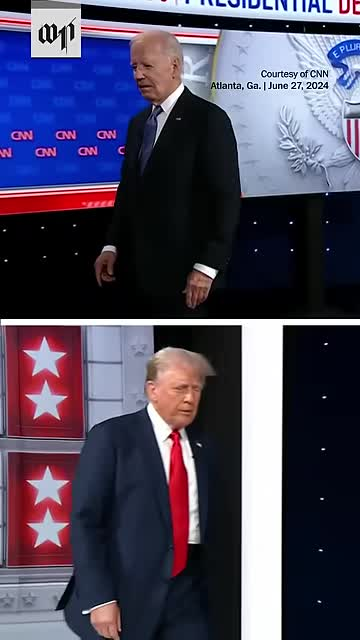
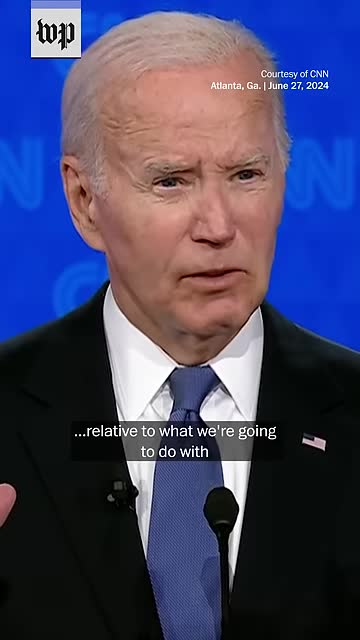
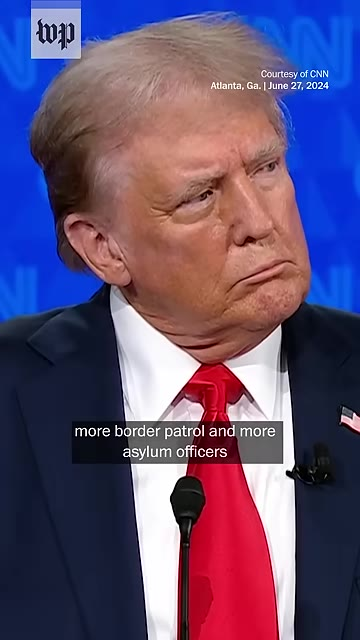
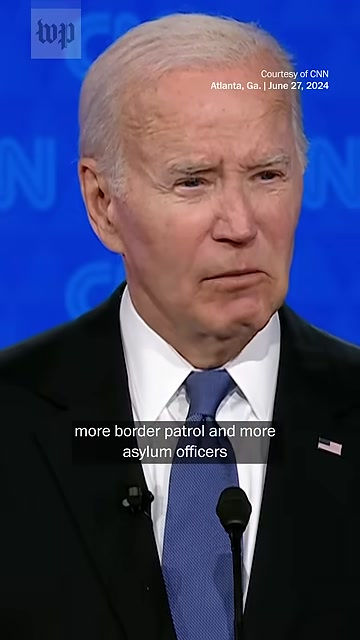
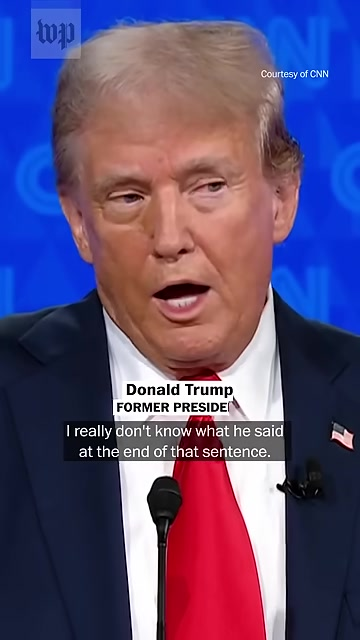
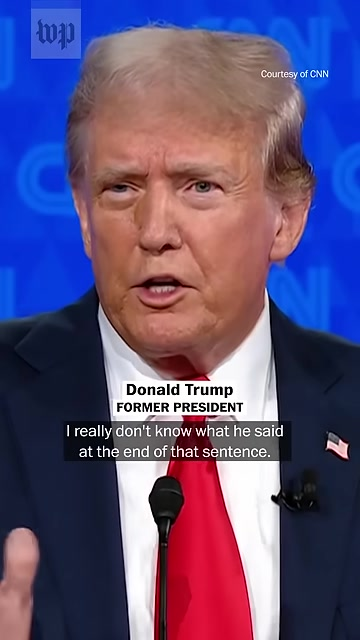
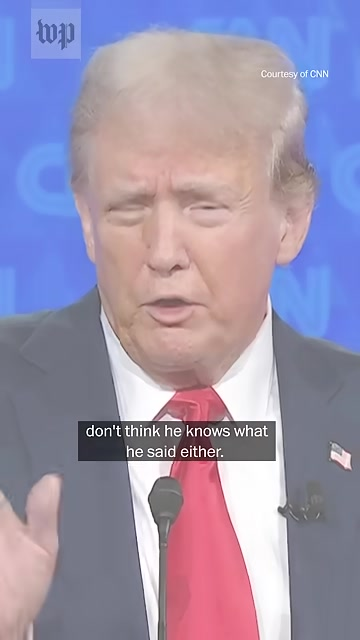
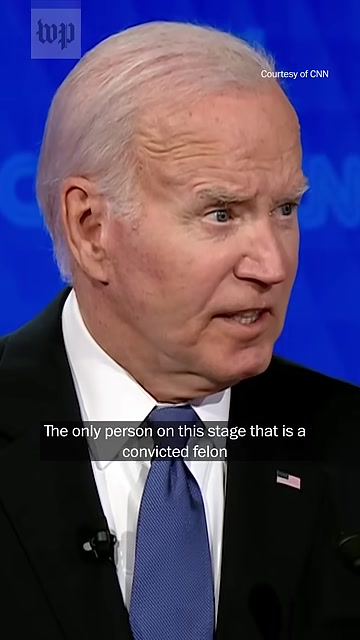
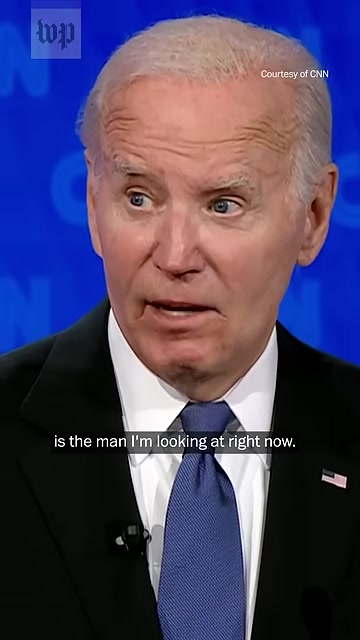
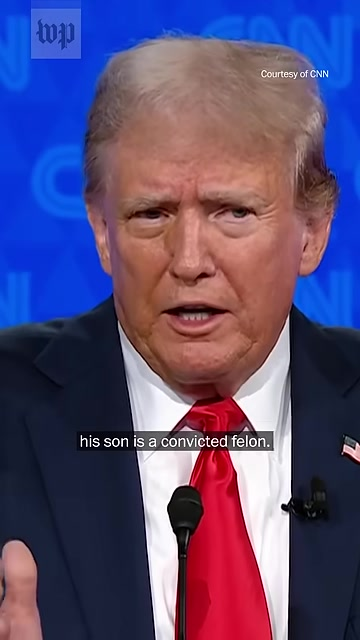
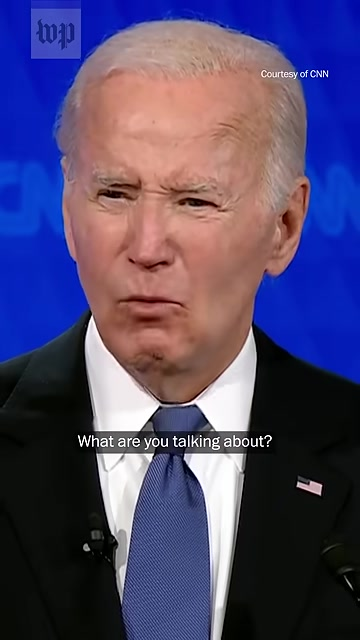
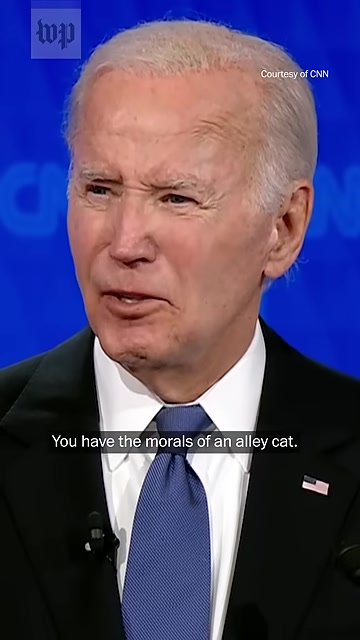
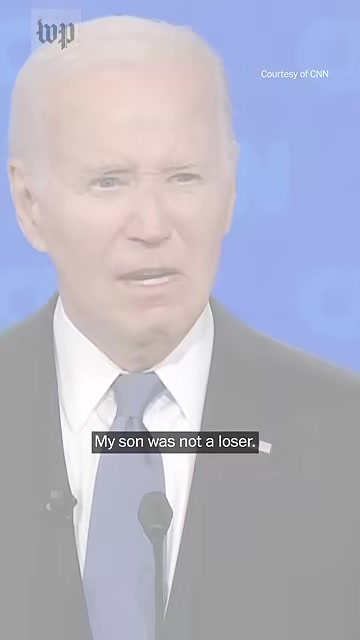
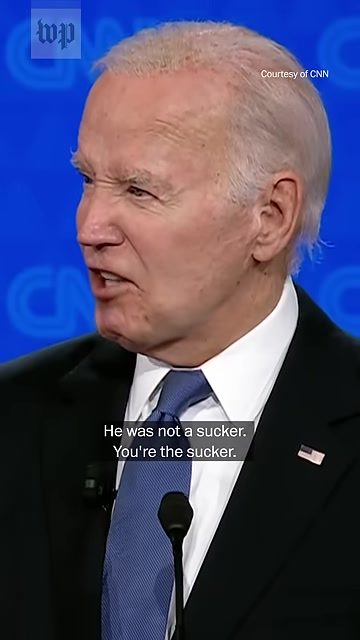
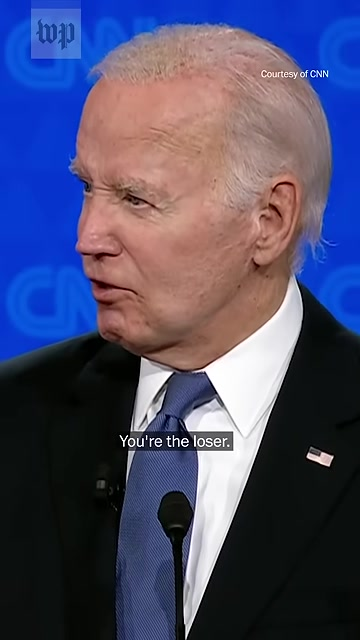

In [3]:
from IPython.display import HTML
import glob, base64
from pathlib import Path

files = sorted(glob.glob("data/debate/*.jpg"))
files = files[:15]
imgs = ""
for f in files:
    data = base64.b64encode(Path(f).read_bytes()).decode()
    mime = Path(f).suffix[1:].replace("jpg", "jpeg")
    imgs += f'<div style="text-align:center"><img src="data:image/{mime};base64,{data}" style="width:100%;border-radius:4px"><div style="font-size:.75em;color:#888">{Path(f).name}</div></div>'
HTML(f'<div style="display:grid;grid-template-columns:repeat(5,1fr);gap:8px">{imgs}</div>')


Even if the vibe answer was right, sometimes verification is more important than ease of use.

## What's this for?

These are the pipelines behind real investigations!

- [Documented examined hundreds of TikTok videos](https://pulitzercenter.org/misinformation-tiktok-how-documented-examined-hundreds-videos-different-languages): download, extract audio, transcribe with Whisper.
- [Público processed 7,616 TikTok health videos](https://www.publico.pt/interactivos/tiktok-desinformacao-saude-pernas-compridas) the same way, then used GPT-4o to extract verifiable claims from the transcripts.
- DW used a [custom detection model](https://universe.roboflow.com/menegat/brasileirao-pitch-ads) to [count betting ads in Brazilian football](https://www.dw.com/en/betting-ads-swamp-brazilian-football-as-addiction-spikes/a-72941493) broadcasts


**Up next:** Putting it all together — full pipelines and checking your work.
